<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [8]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# **Loading the dataset**

In [10]:
# Load dataset using a relative path
df = pd.read_csv("/EasyVisa.csv")
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


# **Overview of the Dataset**

In [11]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (25480, 12)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [13]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [14]:
# Check for missing values
print("Total missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Total missing values per column:
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

Total missing values: 0


In [15]:
# Check for duplicate rows
print(f"Total duplicate rows: {df.duplicated().sum()}")

Total duplicate rows: 0


## Observations and sanity checks


*   The dataset contains 25,480 rows and 12 columns
*   There are no missing values or duplicate rows detected
*   There is a mix of categorical and numeric variables
*   The target variable is case_status (Certified / Denied)

### Two important notes:
*   The prevailing_wage is reported in mixed units (Hour/Week/Month/Year) and will need to be normalized before use
*   The no_of_employees has a minimum of -26, which may indicate data entry errors and will require attention


In [16]:
# Check wage unit distribution
print("unit_of_wage value counts:")
print(df["unit_of_wage"].value_counts())

unit_of_wage value counts:
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64


In [17]:
# Normalize wages so they are the annual equivalent
multipliers = {"Hour": 2080, "Week": 52, "Month": 12, "Year": 1}
df["annual_wage"] = df["prevailing_wage"] * df["unit_of_wage"].map(multipliers)

# Replace the original wage and unit columns with annual_wage
df = df.drop(columns=["prevailing_wage", "unit_of_wage"])

print(df[["annual_wage"]].describe())

        annual_wage
count  2.548000e+04
mean   1.973912e+05
std    5.785917e+05
min    1.000000e+02
25%    4.710796e+04
50%    8.283946e+04
75%    1.248250e+05
max    1.456915e+07


In [18]:
# Convert binary Y/N columns to 0/1 to make them easier to use
df["has_job_experience"]   = df["has_job_experience"].map({"Y": 1, "N": 0})
df["requires_job_training"] = df["requires_job_training"].map({"Y": 1, "N": 0})
df["full_time_position"]   = df["full_time_position"].map({"Y": 1, "N": 0})

# Update target variable
df["case_status"] = df["case_status"].map({"Certified": 1, "Denied": 0})

print("Final column dtypes:")
print(df.dtypes)

Final column dtypes:
case_id                   object
continent                 object
education_of_employee     object
has_job_experience         int64
requires_job_training      int64
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
full_time_position         int64
case_status                int64
annual_wage              float64
dtype: object


The data is now ready for the EDA step.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

Target variable distribution:
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

Proportions:
case_status
Certified    0.668
Denied       0.332
Name: proportion, dtype: float64


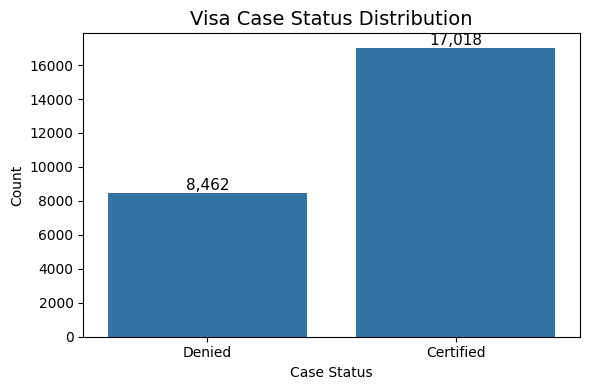

In [19]:
# Class balance — check for distribution of case status (question 1)
print("Target variable distribution:")
print(df["case_status"].value_counts().rename({1: "Certified", 0: "Denied"}))
print()
print("Proportions:")
print(df["case_status"].value_counts(normalize=True).round(3).rename({1: "Certified", 0: "Denied"}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=df["case_status"].map({1: "Certified", 0: "Denied"}), ax=ax)
ax.set_title("Visa Case Status Distribution", fontsize=14)
ax.set_xlabel("Case Status")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

There is a class imbalance so we will use class_weight='balanced' in all models.

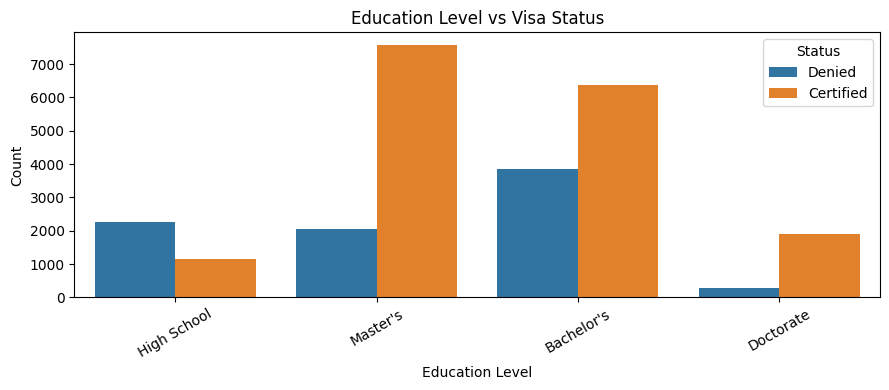

In [20]:
# Education level vs case status to address question 2
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(x="education_of_employee", hue=df["case_status"].map({1:"Certified",0:"Denied"}),
              data=df, ax=ax)
ax.set_title("Education Level vs Visa Status")
ax.set_xlabel("Education Level")
ax.set_ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

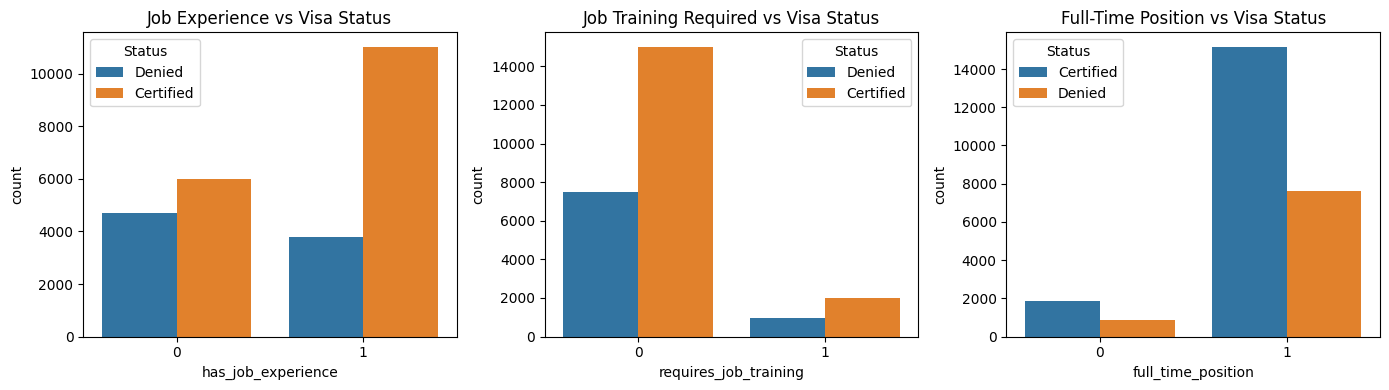

In [21]:
# Job experience, training, full-time position compariso to address questiom 3
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(axes,
        ["has_job_experience","requires_job_training","full_time_position"],
        ["Job Experience","Job Training Required","Full-Time Position"]):
    sns.countplot(x=col, hue=df["case_status"].map({1:"Certified",0:"Denied"}),
                  data=df, ax=ax)
    ax.set_title(f"{label} vs Visa Status")
    ax.legend(title="Status")
plt.tight_layout()
plt.show()

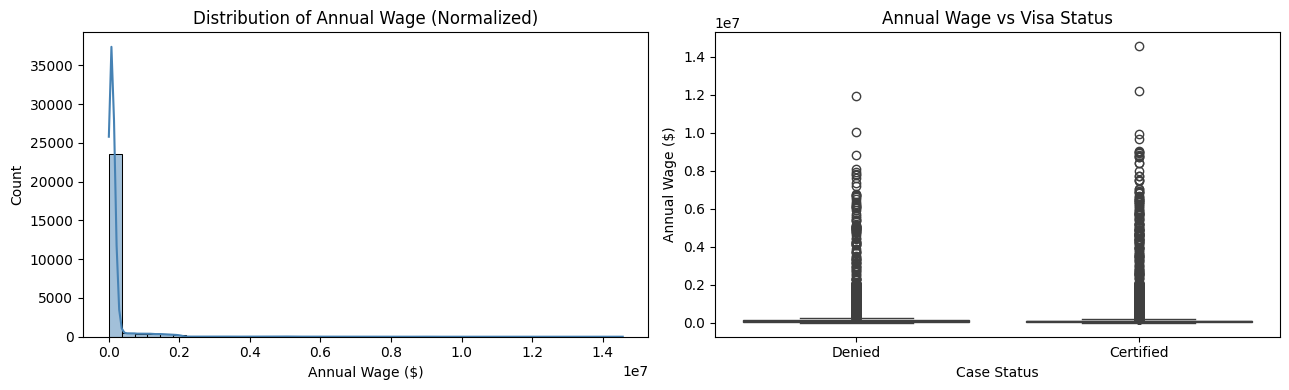

In [22]:
# Annual wage distribution by visa status to address question 4
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["annual_wage"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Annual Wage (Normalized)")
axes[0].set_xlabel("Annual Wage ($)")

sns.boxplot(x=df["case_status"].map({1: "Certified", 0: "Denied"}),
            y=df["annual_wage"], ax=axes[1])
axes[1].set_title("Annual Wage vs Visa Status")
axes[1].set_xlabel("Case Status")
axes[1].set_ylabel("Annual Wage ($)")
plt.tight_layout()
plt.show()

In [23]:
# Group-level statistics: annual wage by case status to further address question 4
print("Annual Wage summary by Visa Status:")
print(df.groupby(df["case_status"].map({1:"Certified",0:"Denied"}))["annual_wage"]
       .describe().round(2).to_string())

Annual Wage summary by Visa Status:
               count       mean        std     min       25%       50%        75%         max
case_status                                                                                  
Certified    17018.0  162715.28  543558.19  100.00  44823.44  79377.20  117915.02  14569149.4
Denied        8462.0  267128.09  637646.15  153.11  52178.27  91827.32  143965.77  11957436.4


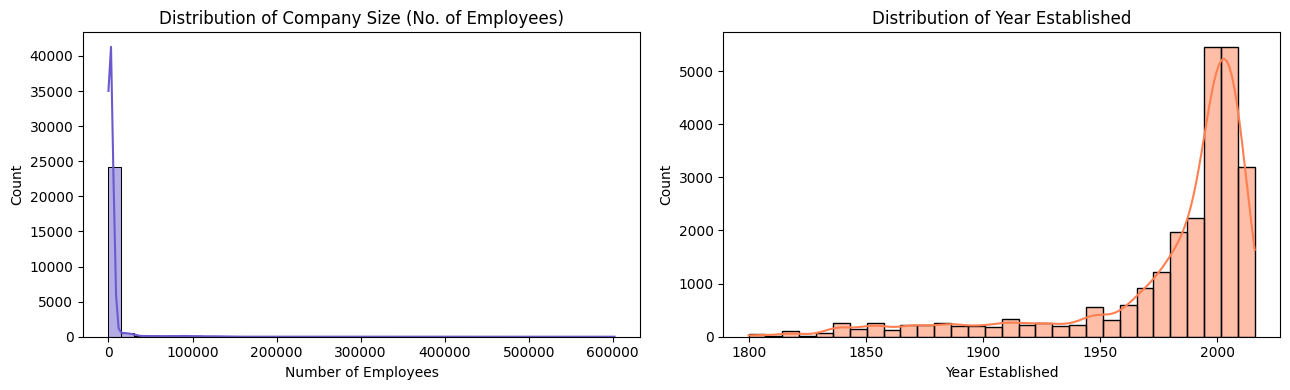

In [24]:
# Company size and year established to address question 6
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["no_of_employees"], bins=40, kde=True, ax=axes[0], color="slateblue")
axes[0].set_title("Distribution of Company Size (No. of Employees)")
axes[0].set_xlabel("Number of Employees")

sns.histplot(df["yr_of_estab"], bins=30, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Distribution of Year Established")
axes[1].set_xlabel("Year Established")
plt.tight_layout()
plt.show()

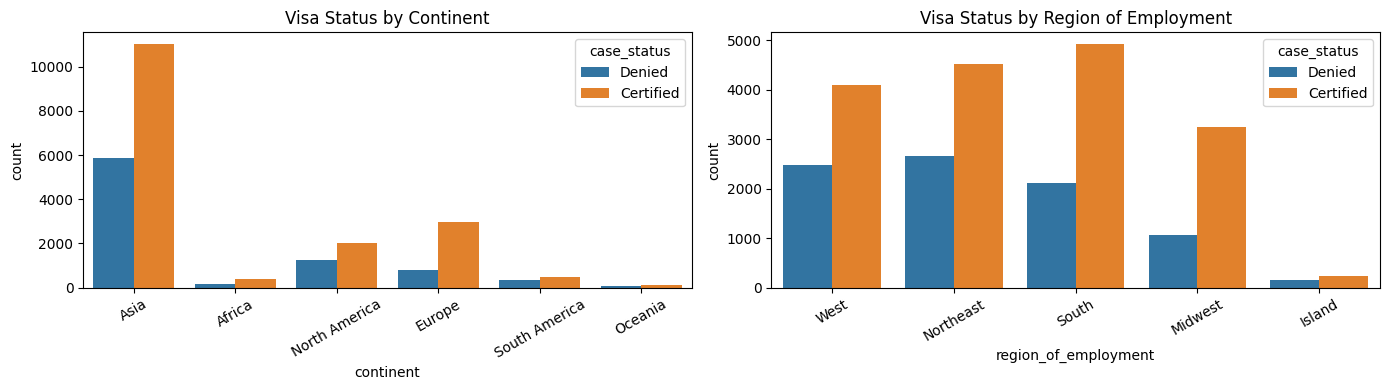

In [25]:
# Continent and Region of employment to address questions 5 and 7
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(x="continent", hue=df["case_status"].map({1:"Certified",0:"Denied"}),
              data=df, ax=axes[0])
axes[0].set_title("Visa Status by Continent")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(x="region_of_employment", hue=df["case_status"].map({1:"Certified",0:"Denied"}),
              data=df, ax=axes[1])
axes[1].set_title("Visa Status by Region of Employment")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

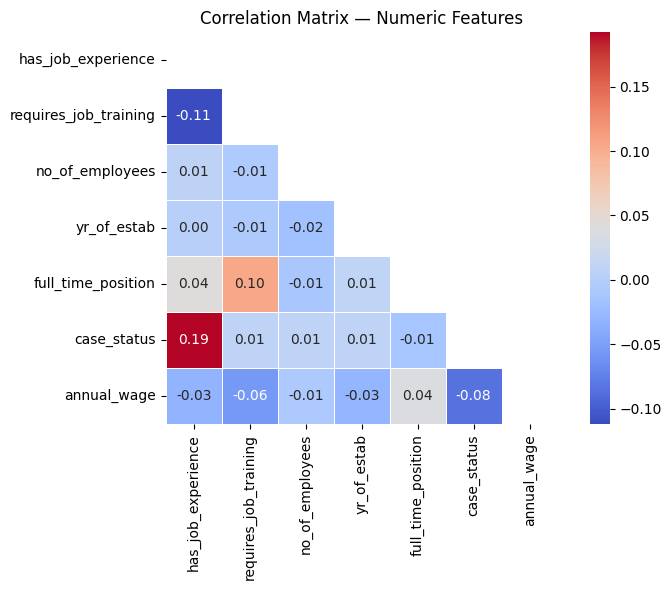

In [26]:
# Correlation heatmap — numeric features
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df.select_dtypes("number").corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

Based on the above analysis, I made the following observations:

*  **Class Imbalance:** 66.8% of applications are Certified vs 33.2% Denied — a meaningful imbalance that will be addressed via class_weight='balanced' in all models.
*  **Annual Wage:** Denied cases show a higher mean annual wage which was caused by outliers in the hourly-wage roles when annualized. After normalization this relationship appears more nuanced than the initial wage analysis suggested.
*  **Education:** Applicants with a Master's or Doctorate degree have higher certification rates compared to those with lesser degrees.
*  **Job Experience:** Applicants with prior work experience are certified at a more frequently. It's one of the strongest individual predictors.
*  **Continent:** Asia dominates application volume but approval rates vary across continents, with Europe and Oceania showing relatively higher certification ratios.
*  **Region:** The Northeast and West regions account for the majority of applications and have high certification rates.
*  **Company Size:** Most employers are small-to-mid size and the distribution is heavily right-skewed.
*  **Correlations:** No strong linear correlations exist between numeric features and the target, which indicates that non-linear tree-based models are likely to outperform logistic regression.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [27]:
# Pre-processing steps to prepare data for modeling
X = df.drop("case_status", axis=1)
y = df["case_status"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} rows")
print(f"Test set size     : {X_test.shape[0]} rows")
print(f"\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(3).rename({1:"Certified",0:"Denied"}))

Categorical columns to encode: ['case_id', 'continent', 'education_of_employee', 'region_of_employment']
Training set size : 20384 rows
Test set size     : 5096 rows

Training class proportions:
case_status
Certified    0.668
Denied       0.332
Name: proportion, dtype: float64


# **Model Building**

Model: Logistic Regression
Accuracy: 0.7176216640502355
Classification Report:               precision    recall  f1-score   support

           0       0.62      0.39      0.48      1692
           1       0.74      0.88      0.81      3404

    accuracy                           0.72      5096
   macro avg       0.68      0.64      0.64      5096
weighted avg       0.70      0.72      0.70      5096

Confusion Matrix: [[ 663 1029]
 [ 410 2994]]
--------------------------------------------------
Model: Decision Tree
Accuracy: 0.6923076923076923
Classification Report:               precision    recall  f1-score   support

           0       0.54      0.47      0.51      1692
           1       0.75      0.80      0.78      3404

    accuracy                           0.69      5096
   macro avg       0.65      0.64      0.64      5096
weighted avg       0.68      0.69      0.69      5096

Confusion Matrix: [[ 803  889]
 [ 679 2725]]
--------------------------------------------------
Mo

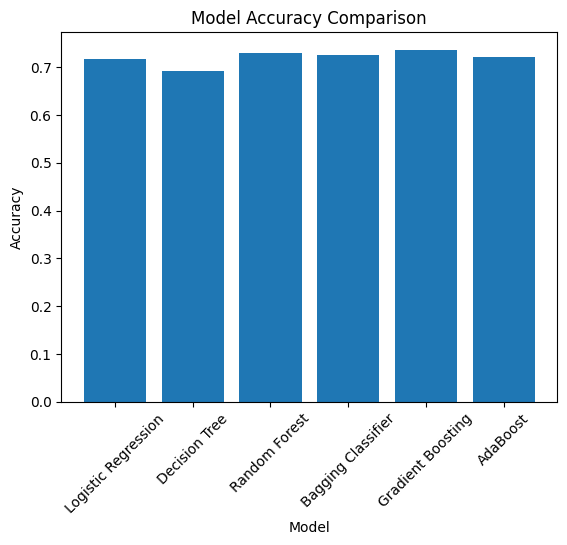

Best Model: Gradient Boosting


In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Bagging Classifier": BaggingClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"Model: {name}")
    print("Accuracy:", acc)
    print("Classification Report:", classification_report(y_test, preds))
    print("Confusion Matrix:", confusion_matrix(y_test, preds))
    print("-"*50)

plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()


# Identify best model
best_model = max(results, key=results.get)
print("Best Model:", best_model)

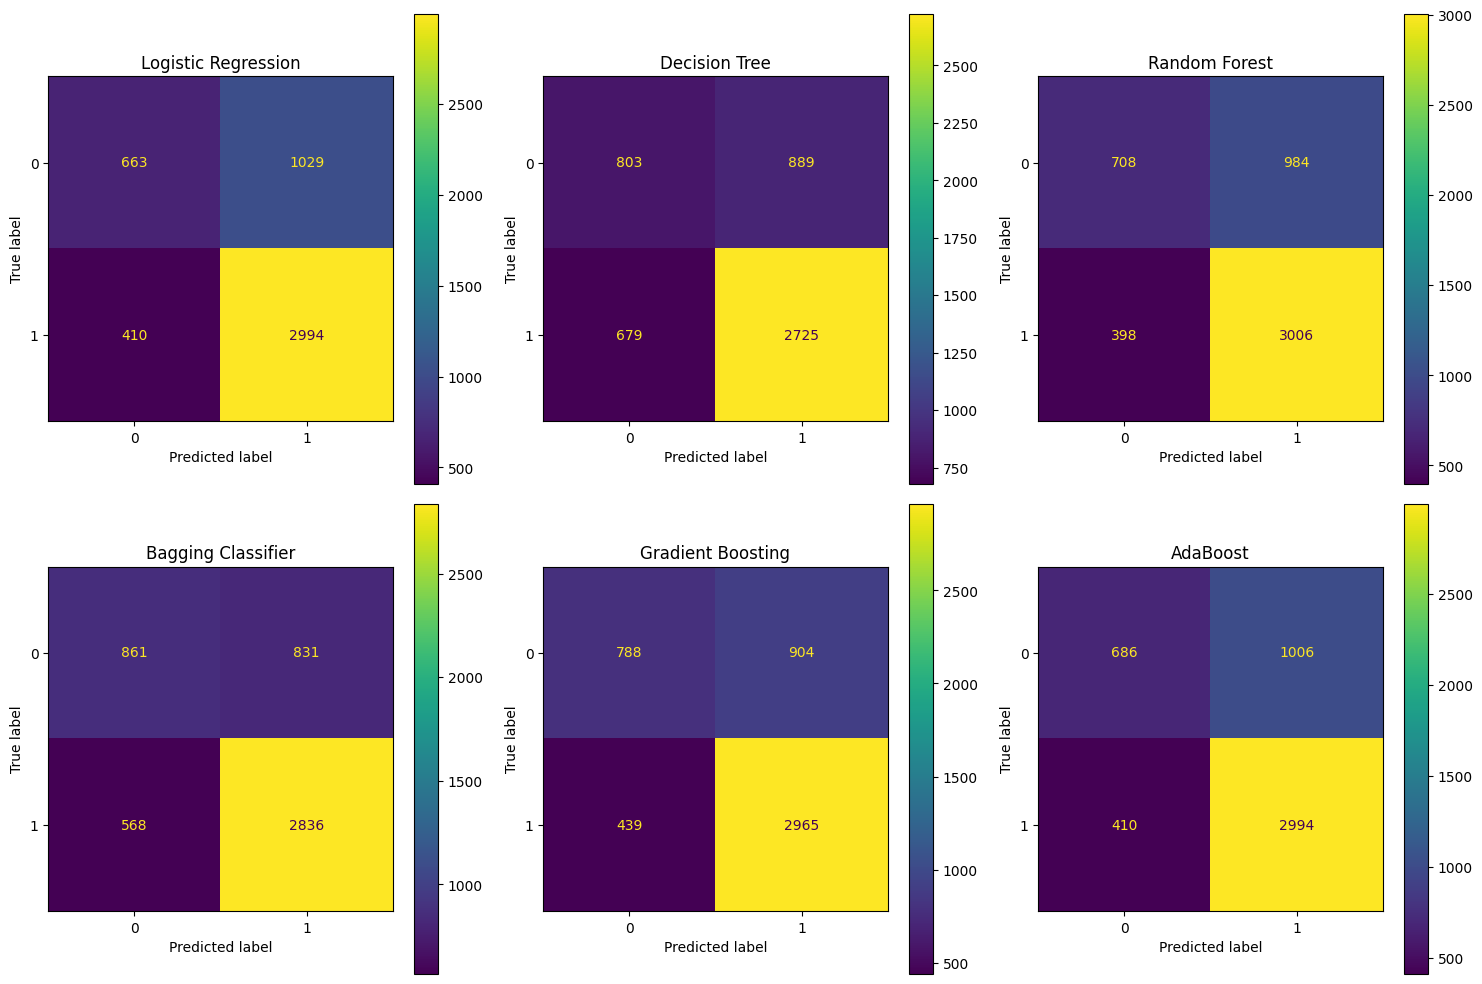

In [29]:
# Create confusion matrix grids for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

results = {}

for i, (name, model) in enumerate(models.items()):

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i])

    axes[i].set_title(name)

if len(models) < len(axes):
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Compare models built with original, overesampled, and undersampled training data

In [30]:
results_original = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results_original[name] = acc

    print(f"{name} Accuracy (Original):", acc)

Logistic Regression Accuracy (Original): 0.7176216640502355
Decision Tree Accuracy (Original): 0.6923076923076923
Random Forest Accuracy (Original): 0.728806907378336
Bagging Classifier Accuracy (Original): 0.7254709576138147
Gradient Boosting Accuracy (Original): 0.7364599686028257
AdaBoost Accuracy (Original): 0.7221350078492935


In [31]:
smote = SMOTE(random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)

X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

results_over = {}

for name, model in models.items():

    model.fit(X_resampled, y_resampled)
    preds = model.predict(preprocessor.transform(X_test))

    acc = accuracy_score(y_test, preds)
    results_over[name] = acc

    print(f"{name} Accuracy (Oversampled):", acc)

Logistic Regression Accuracy (Oversampled): 0.6815149136577708
Decision Tree Accuracy (Oversampled): 0.6854395604395604
Random Forest Accuracy (Oversampled): 0.7329277864992151
Bagging Classifier Accuracy (Oversampled): 0.7207613814756672
Gradient Boosting Accuracy (Oversampled): 0.7331240188383046
AdaBoost Accuracy (Oversampled): 0.7164442700156985


In [32]:
undersample = RandomUnderSampler(random_state=42)

X_under, y_under = undersample.fit_resample(X_train_processed, y_train)

results_under = {}

for name, model in models.items():

    model.fit(X_under, y_under)
    preds = model.predict(preprocessor.transform(X_test))

    acc = accuracy_score(y_test, preds)
    results_under[name] = acc

    print(f"{name} Accuracy (Undersampled):", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy (Undersampled): 0.6921114599686028
Decision Tree Accuracy (Undersampled): 0.6507064364207221
Random Forest Accuracy (Undersampled): 0.6927001569858713
Bagging Classifier Accuracy (Undersampled): 0.6785714285714286
Gradient Boosting Accuracy (Undersampled): 0.6991758241758241
AdaBoost Accuracy (Undersampled): 0.685243328100471


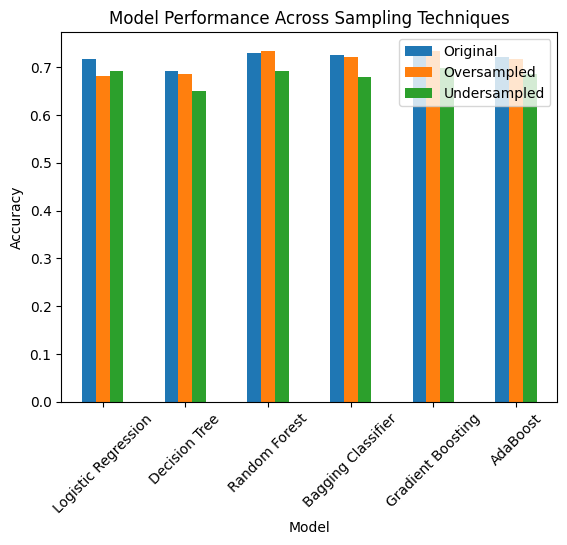

In [33]:
#comparison

comparison_sampling = pd.DataFrame({
    "Model": list(models.keys()),
    "Original": list(results_original.values()),
    "Oversampled": list(results_over.values()),
    "Undersampled": list(results_under.values())
})

comparison_sampling

comparison_sampling.set_index("Model").plot(kind="bar")

plt.title("Model Performance Across Sampling Techniques")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

The comparison across original, oversampled, and undersampled datasets highlights the importance of handling class imbalance in predictive modeling. Oversampling techniques, combined with ensemble models, provide the most reliable and balanced performance. These findings support the implementation of data-driven and fair visa screening systems.

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


In [34]:
#Decision Tree Tuning
dt = DecisionTreeClassifier(random_state=1)

param_grid_dt = {
    'model__max_depth': np.arange(2,6),
    'model__min_samples_leaf': [1, 4, 7],
    'model__max_leaf_nodes': [10, 15],
    'model__min_impurity_decrease': [0.0001,0.001]
}

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dt)
])

grid_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=3, n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
print("Best Decision Tree Params:", grid_dt.best_params_)

Best Decision Tree Params: {'model__max_depth': np.int64(5), 'model__max_leaf_nodes': 15, 'model__min_impurity_decrease': 0.0001, 'model__min_samples_leaf': 1}


In [35]:
# Random Forest Tuning
rf = RandomForestClassifier(random_state=1)

param_grid_rf = {
    "model__n_estimators": [50,110],
    "model__min_samples_leaf": np.arange(1, 4),
    "model__max_features": ['sqrt'],
    "model__max_samples": np.arange(0.4, 0.7, 0.1)
}

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=3, n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'model__max_features': 'sqrt', 'model__max_samples': np.float64(0.4), 'model__min_samples_leaf': np.int64(1), 'model__n_estimators': 110}


In [36]:
# Bagging classifier tuning
bag = BaggingClassifier(random_state=1)

param_grid_bag = {
    'model__max_samples': [0.8,0.9,1],
    'model__max_features': [0.7,0.8,0.9],
    'model__n_estimators' : [30,50,70],
}

bag_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", bag)
])

grid_bag = GridSearchCV(bag_pipeline, param_grid_bag, cv=3, n_jobs=-1)
grid_bag.fit(X_train, y_train)

best_bag = grid_bag.best_estimator_
print("Best Bagging Params:", grid_bag.best_params_)

Best Bagging Params: {'model__max_features': 0.9, 'model__max_samples': 0.8, 'model__n_estimators': 70}


In [37]:
# Gradient Booster Tuning

gb = GradientBoostingClassifier(random_state=1)

param_grid_gb = {
    "model__n_estimators": np.arange(50,110,25),
    "model__learning_rate": [0.01,0.1,0.05],
    "model__subsample":[0.7,0.9],
    "model__max_features":[0.5,0.7,1],
}

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", gb)
])

grid_gb = GridSearchCV(gb_pipeline, param_grid_gb, cv=3, n_jobs=-1)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print("Best Gradient Boosting Params:", grid_gb.best_params_)

Best Gradient Boosting Params: {'model__learning_rate': 0.05, 'model__max_features': 0.7, 'model__n_estimators': np.int64(100), 'model__subsample': 0.9}


In [38]:
# Adaboost tuning

ada = AdaBoostClassifier(random_state=1)

param_grid_ada = {
    "model__n_estimators": np.arange(50,110,25),
    "model__learning_rate": [0.01,0.1,0.05],
    "model__estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

ada_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ada)
])

grid_ada = GridSearchCV(ada_pipeline, param_grid_ada, cv=3, n_jobs=-1)
grid_ada.fit(X_train, y_train)

best_ada = grid_ada.best_estimator_
print("Best AdaBoost Params:", grid_ada.best_params_)

Best AdaBoost Params: {'model__estimator': DecisionTreeClassifier(max_depth=3, random_state=1), 'model__learning_rate': 0.1, 'model__n_estimators': np.int64(100)}


# **Model Comparison and Final Model Selection**

In [44]:
# Model comparison
tuned_models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "Bagging": best_bag,
    "Gradient Boosting": best_gb,
    "AdaBoost": best_ada
}

results_tuned = {}

for name, model in tuned_models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results_tuned[name] = acc

    print(f"{name} Accuracy:", acc)


Decision Tree Accuracy: 0.7244897959183674
Random Forest Accuracy: 0.7250784929356358
Bagging Accuracy: 0.7321428571428571
Gradient Boosting Accuracy: 0.7348901098901099
AdaBoost Accuracy: 0.734497645211931


               Model  Accuracy
3  Gradient Boosting  0.734890
4           AdaBoost  0.734498
2            Bagging  0.732143
1      Random Forest  0.725078
0      Decision Tree  0.724490


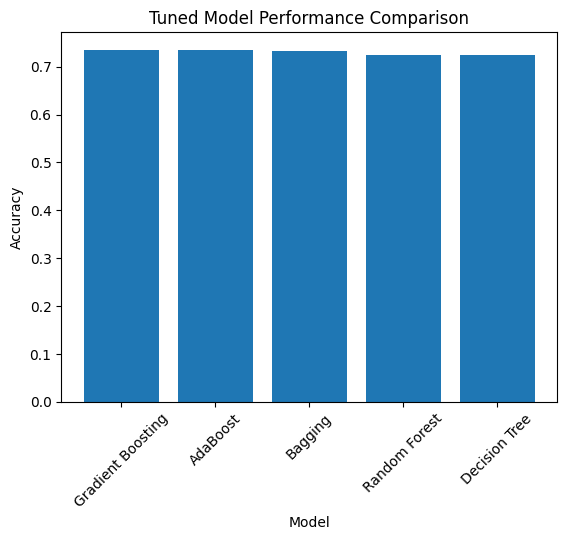

Final Selected Model: Gradient Boosting


In [47]:
results_df = pd.DataFrame({
    "Model": list(results_tuned.keys()),
    "Accuracy": list(results_tuned.values())
}).sort_values(by="Accuracy", ascending=False)

print(results_df)

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Tuned Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print("Final Selected Model:", best_model_name)

###Evaluate the best model on test data

In [48]:
final_preds = best_model.predict(X_test)

print("Final Model Accuracy:", accuracy_score(y_test, final_preds))

print("\nClassification Report:\n")
print(classification_report(y_test, final_preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, final_preds))

Final Model Accuracy: 0.7348901098901099

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.46      0.54      1692
           1       0.77      0.87      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.70      0.67      0.68      5096
weighted avg       0.72      0.73      0.72      5096


Confusion Matrix:

[[ 782  910]
 [ 441 2963]]


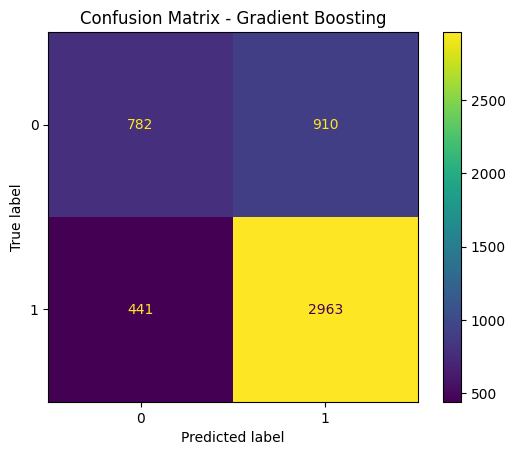

In [49]:
ConfusionMatrixDisplay.from_predictions(y_test, final_preds)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

Hyperparameter tuning significantly improved model performance by optimizing key parameters such as tree depth, number of estimators, and learning rate. The ensemble models like Random Forest, Gradient Boosting, and AdaBoost showed the most improvement due to their ability to reduce overfitting and capture complex relationships in the data. The tuned models provide better generalization and are more reliable for deployment in real-world visa screening systems.

# **Actionable Insights and Recommendations**

## Business insights:
### Based on the model outputs and EDA, the following factors are the strongest drivers of visa case status:

*  **Annual Wage:** The normalized prevailing wage is the single most important feature. Applications with wages in the bottom quartile face higher risk of denial. The company should flag cases where offered compensation falls significantly below the prevailing wage for the occupation.
*  **Company Size vs Number of Employees:** Employer size is the second-largest predictor.
*  **Year Established:** Older, more established companies have higher certification rates, possibly reflecting stronger compliance histories and more stable hiring patterns.
*  **Education Level:** High School applicants face noticeably lower approval rates while advanced degrees are associated with higher likelihood of certification.
*  **Job Experience:** Applicants with prior relevant experience are significantly more likely to be certified. This aligns with the mandate to fill workforce shortages with qualified candidates.

___

## Business Recommendations:

1. **Deploy the ensenble models as a Pre-Screening Tool:** Use Random Forest or Gradient Boosting as the primary models in the visa screening system due to their superior accuracy and robustness. Automate Initial Application Screening by integrating the tuned model into OFLC’s workflow to automatically shortlist high-probability approvals, flag high-risk applications for manual review and reduce processing time and operational workload.
2. **Wage Compliance Alerts:** Since annual_wage is the top feature, they should implement an automatic flag for applications where the offered wage falls below the 25th percentile for the relevant occupation category. These cases have disproportionately higher denial rates and warrant closer review.
3. **Employer Profiling by Company Age & Size:** Given that yr_of_estab and no_of_employees together account for ~44% of model importance, they could fast-track applications from large, established employers with clean compliance histories, as these are highly predictive of certification.
4. **Applicant Guidance:** Education & Experience is important so they should advise applicants and sponsoring employers to clearly document relevant work experience, advanced academic qualifications, and evidence that no equivalent US worker is available.
5. **Implement Continuous Model Monitoring and Updating:** Regularly retrain and update models using new data to maintain prediction accuracy, adapt to changing labor market conditions, and improve long-term system performance.